# SVM Examples

# Influence of the length scale 

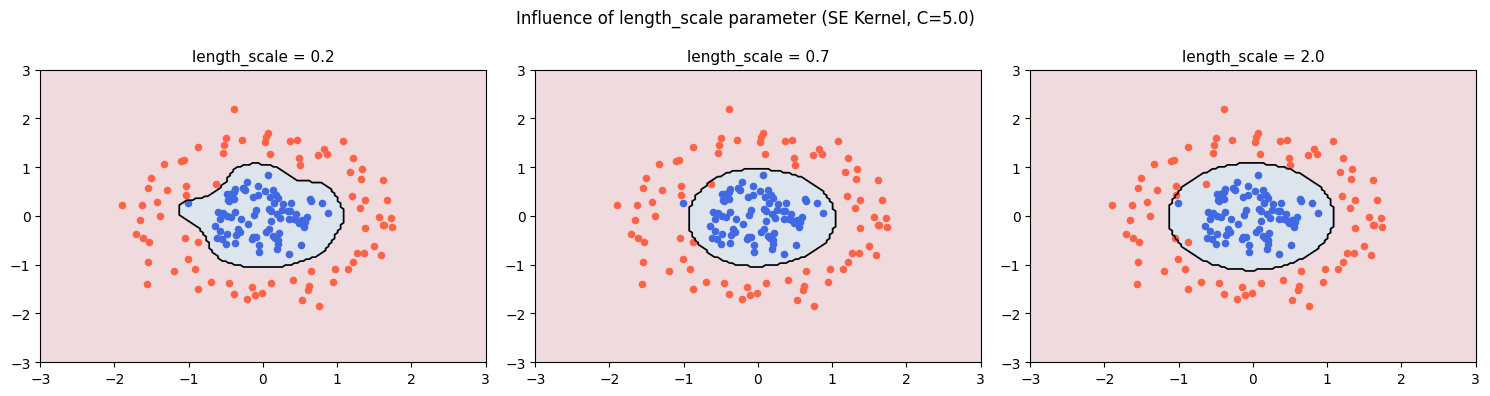

In [1]:
import numpy as np
import jax.numpy as jnp
import SVM
import matplotlib.pyplot as plt
from kernax import SEKernel


np.random.seed(42)
n = 80
theta = np.linspace(0, 2*np.pi, n)
X_InBoundary = np.column_stack([0.5*np.cos(theta),0.5*np.sin(theta)])+0.2*np.random.randn(n, 2)
X_NoBoundary = np.column_stack([1.5*np.cos(theta),1.5*np.sin(theta)])+0.2*np.random.randn(n, 2)
X = np.vstack([X_InBoundary, X_NoBoundary])
y = np.array([1.0]*n + [-1.0]*n)
X_jnp = jnp.array(X, dtype=jnp.float32)
y_jnp = jnp.array(y, dtype=jnp.float32)

XX, YY = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
grid = jnp.array(np.c_[XX.ravel(), YY.ravel()], dtype=jnp.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ls, ax in zip([0.2, 0.7, 2.0], axes):
    svm = SVM.SVM(C=5.0, kernel=SEKernel(length_scale=ls))
    svm.fit(X_jnp, y_jnp, epochs=1000)
    preds = np.array(svm.predict(grid)).reshape(XX.shape)
    ax.contourf(XX, YY, preds, alpha=0.15, cmap='RdBu')
    ax.contour(XX, YY, preds, levels=[0], colors='black', linewidths=1.2)
    ax.scatter(X_InBoundary[:, 0], X_InBoundary[:, 1], c='royalblue', s=20)
    ax.scatter(X_NoBoundary[:, 0], X_NoBoundary[:, 1], c='tomato', s=20)
    ax.set_title(f'length_scale = {ls}', fontsize=11)
plt.suptitle('Influence of length_scale parameter (SE Kernel, C=5.0)', fontsize=12)
plt.tight_layout()
plt.show()

- For length_scale = 0.2 the decision boundary is irregular and fit a lot to the data 

- For length_scale = 0.7 the decision boundary is a lot smoother, and it's correctly separating the data, it's the best choice.

- For length_scale = 2.0 the decision boundary is really smooth but it leads to underfitting.